In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

print(df.shape)
print(df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].head(10))
print("\nSurvival counts:")
print(df['Survived'].value_counts())
print(f"\nMissing Age: {df['Age'].isna().sum()} rows")

(891, 12)
   Survived  Pclass     Sex   Age     Fare
0         0       3    male  22.0   7.2500
1         1       1  female  38.0  71.2833
2         1       3  female  26.0   7.9250
3         1       1  female  35.0  53.1000
4         0       3    male  35.0   8.0500
5         0       3    male   NaN   8.4583
6         0       1    male  54.0  51.8625
7         0       3    male   2.0  21.0750
8         1       3  female  27.0  11.1333
9         1       2  female  14.0  30.0708

Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64

Missing Age: 177 rows


In [2]:
# --- Feature engineering (safe version) ---
df = df.copy()  # avoid pandas chained assignment issues
df['Sex_encoded'] = (df['Sex'] == 'female').astype(int)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())  # Fare has 1 missing too

features = ['Pclass', 'Sex_encoded', 'Age', 'Fare']
X = df[features]
y = df['Survived']

# Quick sanity check before fitting
print("NaN check:", X.isna().sum().to_dict())
print("Shapes:", X.shape, y.shape)

NaN check: {'Pclass': 0, 'Sex_encoded': 0, 'Age': 0, 'Fare': 0}
Shapes: (891, 4) (891,)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])
pipeline.fit(X_train, y_train)
acc = pipeline.score(X_test, y_test)
print(f"Accuracy: {acc:.4f}")

y_pred = pipeline.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Dead', 'Survived']))

Accuracy: 0.7933

Confusion Matrix:
[[89 16]
 [21 53]]

Classification Report:
              precision    recall  f1-score   support

        Dead       0.81      0.85      0.83       105
    Survived       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [ ]:
y_proba = pipeline.predict_proba(X_test)[:, 1]  # P(survived)

threshold = 0.4  # lower = more aggressive about predicting "survived"
y_pred_low = (y_proba >= threshold).astype(int)

print("=== Threshold = 0.4 ===")
print(confusion_matrix(y_test, y_pred_low))
print(classification_report(y_test, y_pred_low, target_names=['Dead', 'Survived']))

=== Threshold = 0.4 ===
[[83 22]
 [13 61]]
              precision    recall  f1-score   support

        Dead       0.86      0.79      0.83       105
    Survived       0.73      0.82      0.78        74

    accuracy                           0.80       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.81      0.80      0.81       179



In [5]:
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'FN':>6} {'FP':>6}")
print("-" * 58)
for t in np.arange(0.1, 0.95, 0.05):
    y_t = (y_proba >= t).astype(int)
    if y_t.sum() == 0:
        break
    p = precision_score(y_test, y_t, zero_division=0)
    r = recall_score(y_test, y_t)
    f = f1_score(y_test, y_t)
    cm = confusion_matrix(y_test, y_t)
    fn, fp = cm[1][0], cm[0][1]
    print(f"{t:>10.2f} {p:>10.2f} {r:>10.2f} {f:>10.2f} {fn:>6} {fp:>6}")

 Threshold  Precision     Recall         F1     FN     FP
----------------------------------------------------------
      0.10       0.48       0.95       0.64      4     75
      0.15       0.58       0.91       0.71      7     48
      0.20       0.61       0.91       0.73      7     43
      0.25       0.65       0.89       0.75      8     35
      0.30       0.71       0.89       0.79      8     27
      0.35       0.73       0.86       0.79     10     24
      0.40       0.73       0.82       0.78     13     22
      0.45       0.73       0.77       0.75     17     21
      0.50       0.77       0.72       0.74     21     16
      0.55       0.80       0.70       0.75     22     13
      0.60       0.87       0.61       0.71     29      7
      0.65       0.89       0.57       0.69     32      5
      0.70       0.93       0.53       0.67     35      3
      0.75       0.97       0.47       0.64     39      1
      0.80       0.97       0.39       0.56     45      1
      0.85   

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

print(f"AUC Score: {auc:.4f}")
print(f"\nFirst 5 points on the curve:")
for i in range(5):
    print(f"  threshold={thresholds[i]:.2f}  FPR={fpr[i]:.2f}  TPR={tpr[i]:.2f}")

AUC Score: 0.8745

First 5 points on the curve:
  threshold=inf  FPR=0.00  TPR=0.00
  threshold=0.95  FPR=0.00  TPR=0.01
  threshold=0.82  FPR=0.00  TPR=0.39
  threshold=0.80  FPR=0.01  TPR=0.39
  threshold=0.76  FPR=0.01  TPR=0.47


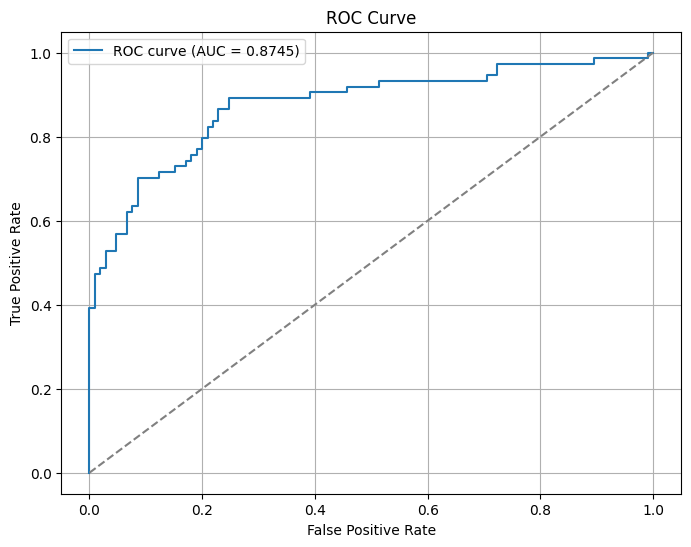

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()  

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000)),
])

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV AUC:", round(grid.best_score_, 4))

# Evaluate best model on test set
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\nTest AUC:", round(roc_auc_score(y_test, y_proba_best), 4))
print("Test Accuracy:", round(best_model.score(X_test, y_test), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Dead', 'Survived']))


NameError: name 'grid' is not defined